# Exploitation du graphe d'influences

In [1]:
from ipysigma import Sigma
import pickle
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
from ipysigma import Sigma
import networkx as nx
import plotly.graph_objects as go
from ipysigma import Sigma
from networkx.algorithms import community as comm
from networkx.algorithms.community import label_propagation_communities

In [2]:
with open("Q205519.pickle", "rb") as f:
    data = pickle.load(f)

In [3]:
def dico_filenames(filename = "cross-era_annotations.csv"):
    dico = {}
    df = pd.read_csv(filename, sep=',')
    for i in range(len(df)):
        dico[df['Filename'][i]] = df['Composer'][i]
    return dico
dico_composers = dico_filenames()
a = np.array(list(dico_composers.values()))
np.unique(a)
# Imprime toutes les clés ayant pour valeur 'major'
for key, value in dico_composers.items():
    if value == ' major':
        print(key)
dico_composers["CrossEra-0616_Borodin_symphony_no.3_in_a_minor_moderato_assai.mp3"] = 'Borodin; Alexander'
dico_composers["CrossEra-0673_Liszt_poems__mazeppa.mp3"] = 'Liszt; Franz'
dico_composers["CrossEra-0674_Liszt_poems__prometheus.mp3"] = 'Liszt; Franz'
dico_composers["CrossEra-0776_Verdi_Overt_giovanna_darco_sinfonia.mp3"] = 'Verdi; Giuseppe'
dico_composers["CrossEra-1016_Cimarosa_Piano_sonata_no._24_in_b-flat_minor_major___andantino.mp3"] = 'Cimarosa; Domenico'

CrossEra-0616_Borodin_symphony_no.3_in_a_minor_moderato_assai.mp3
CrossEra-0673_Liszt_poems__mazeppa.mp3
CrossEra-0674_Liszt_poems__prometheus.mp3
CrossEra-0776_Verdi_Overt_giovanna_darco_sinfonia.mp3
CrossEra-1016_Cimarosa_Piano_sonata_no._24_in_b-flat_minor_major___andantino.mp3


In [4]:
# Load the data
with open("hist_cross-era.pkl", "rb") as f:
    dico_cross_era = pickle.load(f)

In [5]:
X = []
y = []
for file, histograms in dico_cross_era.items():
    composer = dico_composers[file.split('/')[1]]
    print(file)
    matrice = np.vstack(histograms)
    X.append(matrice.flatten())
    y.append(composer)
X = np.array(X)
y = np.array(y)

orchestra_addon/CrossEra-1602_Bach_CPE_sinfonia_in_b_flat_major_wq._182_no._2.mp3
orchestra_addon/CrossEra-1603_Bach_CPE_sinfonia_in_b_minor_wq._182_no._5.mp3
orchestra_addon/CrossEra-1604_Bach_CPE_sinfonia_in_c_major_wq._182_no._3.mp3
orchestra_addon/CrossEra-1605_Bach_CPE_sinfonia_in_e_major_wq._182_no._6.mp3
orchestra_addon/CrossEra-1606_Bach_CPE_sinfonia_in_g_major_wq._182_no._1.mp3
orchestra_addon/CrossEra-1607_Beethoven_egmont_overture_op.84.mp3
orchestra_addon/CrossEra-1608_beethoven_no002_01_adagio_molto__allegro_con_brio.mp3
orchestra_addon/CrossEra-1609_beethoven_no002_02_larghetto.mp3
orchestra_addon/CrossEra-1610_beethoven_no002_03_scherzo__allegro.mp3
orchestra_addon/CrossEra-1611_beethoven_no002_04_allegro_molto.mp3
orchestra_addon/CrossEra-1612_Beethoven_overt_consecration_of_the_house.mp3
orchestra_addon/CrossEra-1613_Beethoven_overt_coriolanus.mp3
orchestra_addon/CrossEra-1614_Beethoven_overt_creatures_of_prometheus.mp3
orchestra_addon/CrossEra-1615_Beethoven_overt_leo

In [6]:
dico_cross_era.keys()

dict_keys(['orchestra_addon/CrossEra-1602_Bach_CPE_sinfonia_in_b_flat_major_wq._182_no._2.mp3', 'orchestra_addon/CrossEra-1603_Bach_CPE_sinfonia_in_b_minor_wq._182_no._5.mp3', 'orchestra_addon/CrossEra-1604_Bach_CPE_sinfonia_in_c_major_wq._182_no._3.mp3', 'orchestra_addon/CrossEra-1605_Bach_CPE_sinfonia_in_e_major_wq._182_no._6.mp3', 'orchestra_addon/CrossEra-1606_Bach_CPE_sinfonia_in_g_major_wq._182_no._1.mp3', 'orchestra_addon/CrossEra-1607_Beethoven_egmont_overture_op.84.mp3', 'orchestra_addon/CrossEra-1608_beethoven_no002_01_adagio_molto__allegro_con_brio.mp3', 'orchestra_addon/CrossEra-1609_beethoven_no002_02_larghetto.mp3', 'orchestra_addon/CrossEra-1610_beethoven_no002_03_scherzo__allegro.mp3', 'orchestra_addon/CrossEra-1611_beethoven_no002_04_allegro_molto.mp3', 'orchestra_addon/CrossEra-1612_Beethoven_overt_consecration_of_the_house.mp3', 'orchestra_addon/CrossEra-1613_Beethoven_overt_coriolanus.mp3', 'orchestra_addon/CrossEra-1614_Beethoven_overt_creatures_of_prometheus.mp3',

In [7]:
print(f"Taille de X : {X.shape}"
      f"\nTaille de y : {y.shape}"
      f"\nNombre de classes : {len(np.unique(y))}"
      f"\nNombre d'instances : {len(y)}"
      f"\nNombre de features : {X.shape[1]}")

Taille de X : (1990, 4896)
Taille de y : (1990,)
Nombre de classes : 70
Nombre d'instances : 1990
Nombre de features : 4896


## Test de la meilleure dimension

In [8]:
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import NearestNeighbors
from scipy.stats import entropy
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# -------------------------------
# 2. Encodage de y (texte → int)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_
n_classes = len(class_names)
max_lda_dim = n_classes - 1
max_lda_dim = 30

# -------------------------------
# 3. Paramètres
n_neighbors = 7
n_splits = 5
pca_dim = 500
random_state = 42
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

pca = PCA(n_components=pca_dim, random_state=random_state)
X_pca = pca.fit_transform(X_scaled)


# -------------------------------
# 4. Fonction de score : entropie moyenne des votes de voisins
def neighbor_entropy(X_proj, y_labels, n_neighbors, class_count):
    nn = NearestNeighbors(n_neighbors=n_neighbors + 1)  # +1 pour ignorer le point lui-même
    nn.fit(X_proj)
    distances, indices = nn.kneighbors(X_proj)
    
    neighbor_idxs = indices[:, 1:]
    neighbor_votes = y_labels[neighbor_idxs]  # shape (n_samples, n_neighbors)
    
    probs = np.zeros((X_proj.shape[0], class_count))
    for i in range(X_proj.shape[0]):
        for cls in range(class_count):
            probs[i, cls] = np.mean(neighbor_votes[i] == cls)
    
    entropies = entropy(probs.T + 1e-12, base=2)  # T pour (n_classes, n_samples)
    return np.mean(entropies)

# -------------------------------
# 5. Boucle sur les dimensions LDA
scores_by_dim = []

for dim in range(1, max_lda_dim + 1):
    print(f"\n🔍 Dimension LDA : {dim}")
    fold_entropies = []

    for train_idx, test_idx in skf.split(X, y_encoded):
        X_train, X_test = X_pca[train_idx], X_pca[test_idx]
        y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

        lda = LinearDiscriminantAnalysis(n_components=dim, solver='eigen', shrinkage='auto')
        X_train_lda = lda.fit_transform(X_train, y_train)
        X_test_lda = lda.transform(X_test)

        # Calcul de l'entropie sur les points test (votes de leurs 4 voisins dans l'espace projeté)
        fold_entropy = neighbor_entropy(X_test_lda, y_test, n_neighbors, n_classes)
        fold_entropies.append(fold_entropy)

    mean_entropy = np.mean(fold_entropies)
    scores_by_dim.append((dim, mean_entropy))

# -------------------------------
# 6. Résultat
best_dim, best_entropy = min(scores_by_dim, key=lambda x: x[1])
print(f"\n✅ Meilleure dimension LDA : {best_dim} (entropie moyenne = {best_entropy:.4f})")

print("\nDétail des scores par dimension LDA :")
for dim, ent in scores_by_dim:
    print(f"Dimension = {dim:2d} → Entropie moyenne = {ent:.4f}")

# -------------------------------
# 7. Visualisation
dims, entropies = zip(*scores_by_dim)
plt.figure(figsize=(8, 5))
plt.plot(dims, entropies, marker='o', color='purple')
plt.axvline(best_dim, color='red', linestyle='--', label=f"Meilleure dim = {best_dim}")
plt.xlabel('Dimension LDA')
plt.ylabel('Entropie moyenne des votes KNN')
plt.title('Optimisation de la dimension LDA (vote à 4 voisins)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


🔍 Dimension LDA : 1

🔍 Dimension LDA : 2

🔍 Dimension LDA : 3

🔍 Dimension LDA : 4

🔍 Dimension LDA : 5

🔍 Dimension LDA : 6

🔍 Dimension LDA : 7

🔍 Dimension LDA : 8

🔍 Dimension LDA : 9

🔍 Dimension LDA : 10

🔍 Dimension LDA : 11

🔍 Dimension LDA : 12

🔍 Dimension LDA : 13

🔍 Dimension LDA : 14


KeyboardInterrupt: 

## Extraction des centroïdes

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_
n_classes = len(class_names)
lda_dim = 9
n_neighbors = 4
n_splits = 5
pca_dim = 100
random_state = 42
pca = PCA(n_components=pca_dim, random_state=random_state)
X_pca = pca.fit_transform(X_scaled)
lda = LinearDiscriminantAnalysis(n_components=dim, solver='eigen', shrinkage='auto')
X_lda = lda.fit_transform(X_pca, y_encoded)
dico_centroids = {}
for cls in range(n_classes):
    composer = class_names[cls]
    class_points = X_lda[y_encoded == cls]
    centroid = class_points.mean(axis=0)
    dico_centroids[composer] = centroid

# Calcul de la matrice des distances euclidiennes entre centroïdes
centroid_matrix = np.vstack([dico_centroids[composer] for composer in class_names])
distance_matrix = pairwise_distances(centroid_matrix, metric='euclidean')


fig = go.Figure(data=go.Heatmap(
    z=distance_matrix,
    x=class_names,
    y=class_names,
    colorscale='Reds',
    colorbar=dict(title='Distance euclidienne'),
    hovertemplate='De %{y}<br>à %{x}<br>Distance: %{z:.2f}<extra></extra>',
))

fig.update_layout(
    title="Matrice des distances entre compositeurs (centroïdes LDA)",
    xaxis=dict(tickangle=90, tickfont=dict(size=8)),
    yaxis=dict(tickfont=dict(size=8)),
    width=900,
    height=800,
    margin=dict(l=100, b=100, t=50, r=50)
)
fig.show()

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_
n_classes = len(class_names)
lda_dim = 3
n_neighbors = 4
n_splits = 5
pca_dim = 100
random_state = 42
pca = PCA(n_components=pca_dim, random_state=random_state)
X_pca = pca.fit_transform(X_scaled)
lda = LinearDiscriminantAnalysis(n_components=dim, solver='eigen', shrinkage='auto')
X_lda = lda.fit_transform(X_pca, y_encoded)
dico_centroids = {}
dico_classes = {}
for cls in range(n_classes):
    composer = class_names[cls]
    dico_classes[cls] = composer
    class_points = X_lda[y_encoded == cls]
    centroid = class_points.mean(axis=0)
    dico_centroids[composer] = centroid

# Calcul de la matrice des distances euclidiennes entre centroïdes
centroid_matrix = np.vstack([dico_centroids[composer] for composer in class_names])
distance_matrix = pairwise_distances(centroid_matrix, metric='euclidean')


fig = go.Figure(data=go.Heatmap(
    z=distance_matrix,
    x=class_names,
    y=class_names,
    colorscale='Viridis',
    colorbar=dict(title='Distance euclidienne'),
    hovertemplate='De %{y}<br>à %{x}<br>Distance: %{z:.2f}<extra></extra>',
))

fig.update_layout(
    title="Matrice des distances entre compositeurs (centroïdes LDA)",
    xaxis=dict(tickangle=90, tickfont=dict(size=8)),
    yaxis=dict(tickfont=dict(size=8)),
    width=900,
    height=800,
    margin=dict(l=100, b=100, t=50, r=50)
)
fig.show()

centroids_3d = np.vstack([dico_centroids[composer][:3] for composer in class_names])
fig_3d = go.Figure(data=[go.Scatter3d(
    x=centroids_3d[:, 0],
    y=centroids_3d[:, 1],
    z=centroids_3d[:, 2],
    mode='markers',
    marker=dict(size=7, color='royalblue', opacity=0.8),
    text=class_names,
    hovertemplate='<b>%{text}</b><br>x: %{x:.2f}<br>y: %{y:.2f}<br>z: %{z:.2f}<extra></extra>',
    showlegend=False
)])
fig_3d.update_layout(
    title="Centroïdes des compositeurs dans l'espace LDA (3D)",
    scene=dict(
        xaxis_title='LDA 1',
        yaxis_title='LDA 2',
        zaxis_title='LDA 3'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)
fig_3d.show()

## Génération du graphe

In [68]:
seuil = 0.65
G = nx.Graph()
for composer, centroid in dico_centroids.items():
    G.add_node(composer, pos=centroid[:3])
for comp1 in dico_centroids:
    for comp2 in dico_centroids:
        if comp1 != comp2:
            dist = np.linalg.norm(dico_centroids[comp1][:3] - dico_centroids[comp2][:3])
            if dist < seuil:
                G.add_edge(comp1, comp2, weight=seuil - dist)

In [69]:
import math

# Définir une colormap bleu-rouge pour les poids des arêtes
import matplotlib
cmap = matplotlib.cm.get_cmap('viridis')

# Normaliser les poids pour la colormap
weights = np.array([d['weight'] for _, _, d in G.edges(data=True)])
w_min, w_max = weights.min(), weights.max()

for u, v, d in G.edges(data=True):
    norm_weight = (d['weight'] - w_min) / (w_max - w_min) if w_max > w_min else 0.5
    rgba = cmap(norm_weight)
    # Convertir en couleur hexadécimale
    d['color_edge'] = matplotlib.colors.rgb2hex(rgba)

layout = {}
grid_positions = {}

angle_step = 2 * math.pi / max(1,len(G.nodes()))
radius = 1
for i,node in enumerate(G.nodes()):
    angle = i * angle_step
    layout[node] = {
        "x": radius * math.cos(angle),
        "y": radius * math.sin(angle)
    }

# Calcul d'un score de PageRank pour ajuster la taille des noeuds par exemple
pagerank_scores = nx.pagerank(G)

# Visualisation avec ipysigma
sigma = Sigma(
    graph=G,
    raw_node_color="color",
    raw_edge_color="color_edge",
    layout=layout,
    node_label="nom complet",
    default_edge_type="curve",
    label_font="cursive",
    node_size=pagerank_scores,  # On peut également multiplier par un facteur si nécessaire
)

# Pour afficher dans Jupyter Notebook (si ipysigma est intégré dans un widget)
sigma

C:\Users\PCAJM\AppData\Local\Temp\ipykernel_18172\1117308282.py:5: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



Sigma(nx.Graph with 70 nodes and 183 edges)

## Calcul de communautés

Nombre de communautés : 9
Nombre de communautés : 10
Nombre de communautés : 11
Nombre de communautés : 12
Nombre de communautés : 13
Nombre de communautés : 14
Nombre de communautés : 15
Nombre de communautés : 16
Nombre de communautés : 17
Nombre de communautés : 18
Nombre de communautés : 19
Nombre de communautés : 20
Nombre de communautés : 21
Nombre de communautés : 22
Nombre de communautés : 23
Nombre de communautés : 24
Nombre de communautés : 25
Nombre de communautés : 26
Nombre de communautés : 27
Nombre de communautés : 28
Nombre de communautés : 29
Nombre de communautés : 30
Nombre de communautés : 31
Nombre de communautés : 32
Nombre de communautés : 33
Nombre de communautés : 34
Nombre de communautés : 35
Nombre de communautés : 36
Nombre de communautés : 37
Nombre de communautés : 38
Nombre de communautés : 39
Nombre de communautés : 40
Nombre de communautés : 41
Nombre de communautés : 42
Nombre de communautés : 43
Nombre de communautés : 44
Nombre de communautés : 45
No

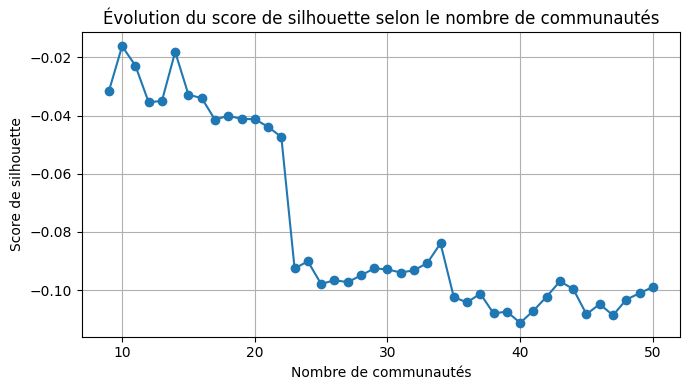

Meilleur score silhouette : -0.0474
Nombre de communautés : 22


In [76]:
from networkx.algorithms.community.centrality import girvan_newman
from networkx import edge_betweenness_centrality as betweenness
from sklearn.metrics import silhouette_score
def most_central_edge(G):
    centrality = betweenness(G, weight="weight")
    return max(centrality, key=centrality.get)
partition = nx.community.girvan_newman(G, most_valuable_edge=most_central_edge)
# Générer les partitions (limité à k=2 à 10 communautés pour éviter trop de calculs)
silhouette_scores = []
partition_lengths = []
best_score = -1
best_partition = None
for communities in partition:
    n_communities = len(communities)
    partition_lengths.append(n_communities)
    print(f"Nombre de communautés : {n_communities}")
    labels = np.zeros(len(G.nodes()), dtype=int)
    for idx, community in enumerate(communities):
        for node in community:
            labels[list(G.nodes()).index(node)] = idx
    # Calcul du score silhouette sur les centroïdes (distance_matrix)
    score = silhouette_score(distance_matrix, labels, metric='precomputed')
    silhouette_scores.append(score)
    if score > best_score or n_communities == 22:
        best_score = score
        best_partition = communities
    if n_communities >= 50:
        break

# Tracer l'évolution du score de silhouette
plt.figure(figsize=(7, 4))
plt.plot(partition_lengths, silhouette_scores, marker='o')
plt.xlabel("Nombre de communautés")
plt.ylabel("Score de silhouette")
plt.title("Évolution du score de silhouette selon le nombre de communautés")
plt.grid(True)
plt.tight_layout()
plt.show()
print(f"Meilleur score silhouette : {best_score:.4f}")
print(f"Nombre de communautés : {len(best_partition)}")

In [77]:
import math

# Définir une colormap bleu-rouge pour les poids des arêtes
import matplotlib
import numpy as np
cmap = matplotlib.cm.get_cmap('coolwarm')
# Générer une couleur différente pour chaque communauté
import matplotlib.colors as mcolors

# Utiliser la meilleure partition trouvée précédemment
communities = best_partition
num_communities = len(communities)
colors = list(mcolors.TABLEAU_COLORS.values())
if num_communities > len(colors):
    # Générer plus de couleurs si besoin
    cmap_communities = matplotlib.cm.get_cmap('tab20', num_communities)
    colors = [matplotlib.colors.rgb2hex(cmap_communities(i)) for i in range(num_communities)]

# Attribuer une couleur à chaque noeud selon sa communauté
node_community_color = {}
for idx, community in enumerate(communities):
    for node in community:
        node_community_color[node] = colors[idx]

# Ajouter la couleur au graphe
for node in G.nodes():
    G.nodes[node]['color'] = node_community_color[node]

# Calculer la disposition des communautés en cercles
layout = {}
radius_outer = 1.5
radius_inner = 0.4
angle_step_outer = 2 * np.pi / num_communities

for idx, community in enumerate(communities):
    angle_center = idx * angle_step_outer
    cx = radius_outer * np.cos(angle_center)
    cy = radius_outer * np.sin(angle_center)
    n_nodes = len(community)
    angle_step_inner = 2 * np.pi / max(n_nodes, 1)
    for j, node in enumerate(community):
        angle = j * angle_step_inner
        layout[node] = {
            "x": cx + radius_inner * np.cos(angle),
            "y": cy + radius_inner * np.sin(angle)
        }

# Calcul d'un score de PageRank pour ajuster la taille des noeuds par exemple
pagerank_scores = nx.pagerank(G)

# Visualisation avec ipysigma
sigma = Sigma(
    graph=G,
    raw_node_color="color",
    raw_edge_color="color_edge",
    layout=layout,
    node_label="nom complet",
    default_edge_type="curve",
    label_font="cursive",
    node_size=pagerank_scores,  # On peut également multiplier par un facteur si nécessaire
)

# Pour afficher dans Jupyter Notebook (si ipysigma est intégré dans un widget)
sigma

C:\Users\PCAJM\AppData\Local\Temp\ipykernel_18172\3783730569.py:6: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.

C:\Users\PCAJM\AppData\Local\Temp\ipykernel_18172\3783730569.py:16: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



Sigma(nx.Graph with 70 nodes and 183 edges)

In [ ]:
import math

# Définir une colormap bleu-rouge pour les poids des arêtes
import matplotlib
import numpy as np
cmap = matplotlib.cm.get_cmap('coolwarm')
# Générer une couleur différente pour chaque communauté
import matplotlib.colors as mcolors

# Utiliser la meilleure partition trouvée précédemment
communities = label_propagation_communities(G)
num_communities = len(communities)
colors = list(mcolors.TABLEAU_COLORS.values())
if num_communities > len(colors):
    # Générer plus de couleurs si besoin
    cmap_communities = matplotlib.cm.get_cmap('tab20', num_communities)
    colors = [matplotlib.colors.rgb2hex(cmap_communities(i)) for i in range(num_communities)]

# Attribuer une couleur à chaque noeud selon sa communauté
node_community_color = {}
for idx, community in enumerate(communities):
    for node in community:
        node_community_color[node] = colors[idx]

# Ajouter la couleur au graphe
for node in G.nodes():
    G.nodes[node]['color'] = node_community_color[node]

# Calculer la disposition des communautés en cercles
layout = {}
radius_outer = 1.5
radius_inner = 0.4
angle_step_outer = 2 * np.pi / num_communities

for idx, community in enumerate(communities):
    angle_center = idx * angle_step_outer
    cx = radius_outer * np.cos(angle_center)
    cy = radius_outer * np.sin(angle_center)
    n_nodes = len(community)
    angle_step_inner = 2 * np.pi / max(n_nodes, 1)
    for j, node in enumerate(community):
        angle = j * angle_step_inner
        layout[node] = {
            "x": cx + radius_inner * np.cos(angle),
            "y": cy + radius_inner * np.sin(angle)
        }

# Calcul d'un score de PageRank pour ajuster la taille des noeuds par exemple
pagerank_scores = nx.pagerank(G)

# Visualisation avec ipysigma
sigma = Sigma(
    graph=G,
    raw_node_color="color",
    raw_edge_color="color_edge",
    layout=layout,
    node_label="nom complet",
    default_edge_type="curve",
    label_font="cursive",
    node_size=pagerank_scores,  # On peut également multiplier par un facteur si nécessaire
)

# Pour afficher dans Jupyter Notebook (si ipysigma est intégré dans un widget)
sigma

C:\Users\PCAJM\AppData\Local\Temp\ipykernel_15232\795474530.py:6: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



Sigma(nx.Graph with 70 nodes and 542 edges)

## Génération d'une autre distance

In [22]:
import ot
from scipy.spatial.distance import cdist
def distance(cls1,cls2,X,y):
    """Calcul de la distance de Wasserstein entre deux distributions de probabilité."""
    # On suppose que cls1 et cls2 sont les labels (valeurs de y) des deux classes à comparer
    # X : matrice des features, y : labels associés (déjà présents dans le notebook)

    # Sélectionner les vecteurs de chaque classe
    X1 = X[y == cls1]
    X2 = X[y == cls2]

    d_xy = cdist(X1, X2, metric='euclidean')
    term_xy = 2 * np.mean(d_xy)

    # Termes intra-classes : E[||x - x'||]
    d_xx = cdist(X1, X1, metric='euclidean')
    term_xx = np.mean(d_xx)

    d_yy = cdist(X2, X2, metric='euclidean')
    term_yy = np.mean(d_yy)

    # Energy distance
    return np.sqrt(term_xy - term_xx - term_yy)

In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_
n_classes = len(class_names)
lda_dim = 3
n_neighbors = 4
n_splits = 5
pca_dim = 100
random_state = 42
pca = PCA(n_components=pca_dim, random_state=random_state)
X_pca = pca.fit_transform(X_scaled)
lda = LinearDiscriminantAnalysis(n_components=dim, solver='eigen', shrinkage='auto')
X_lda = lda.fit_transform(X_pca, y_encoded)
dico_centroids = {}
for cls in range(n_classes):
    composer = class_names[cls]
    class_points = X_lda[y_encoded == cls]
    centroid = class_points.mean(axis=0)
    dico_centroids[composer] = centroid

# Calcul de la matrice des distances euclidiennes entre centroïdes
centroid_matrix = np.vstack([dico_centroids[composer] for composer in class_names])
distance_matrix = np.zeros((n_classes, n_classes))
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j:
            distance_matrix[i, j] = distance(i, j,X,y_encoded)


fig = go.Figure(data=go.Heatmap(
    z=distance_matrix,
    x=class_names,
    y=class_names,
    colorscale='Viridis',
    colorbar=dict(title='Distance euclidienne'),
    hovertemplate='De %{y}<br>à %{x}<br>Distance: %{z:.2f}<extra></extra>',
))

fig.update_layout(
    title="Matrice des distances entre compositeurs (centroïdes LDA)",
    xaxis=dict(tickangle=90, tickfont=dict(size=8)),
    yaxis=dict(tickfont=dict(size=8)),
    width=900,
    height=800,
    margin=dict(l=100, b=100, t=50, r=50)
)
fig.show()

In [78]:
G = nx.Graph()
seuil = 1.3
for value,item in dico_classes.items():
    G.add_node(item, pos=centroid[:3])
for comp1 in range(len(class_names)):
    for comp2 in range(len(class_names)):
        if comp1 != comp2:
            dist = distance_matrix[comp1, comp2]
            if dist < seuil:
                G.add_edge(class_names[comp1], class_names[comp2], weight= seuil-dist)

pickle.dump(G, open(f"graphe_centroids_pot_seuil={seuil}.pkl", "wb"))

In [49]:
import math

# Définir une colormap bleu-rouge pour les poids des arêtes
import matplotlib
cmap = matplotlib.cm.get_cmap('viridis')

# Normaliser les poids pour la colormap
weights = np.array([d['weight'] for _, _, d in G.edges(data=True)])
w_min, w_max = weights.min(), weights.max()

for u, v, d in G.edges(data=True):
    norm_weight = (d['weight'] - w_min) / (w_max - w_min) if w_max > w_min else 0.5
    rgba = cmap(norm_weight)
    # Convertir en couleur hexadécimale
    d['color_edge'] = matplotlib.colors.rgb2hex(rgba)

layout = {}
grid_positions = {}

angle_step = 2 * math.pi / max(1,len(G.nodes()))
radius = 1
for i,node in enumerate(G.nodes()):
    angle = i * angle_step
    layout[node] = {
        "x": radius * math.cos(angle),
        "y": radius * math.sin(angle)
    }

# Calcul d'un score de PageRank pour ajuster la taille des noeuds par exemple
pagerank_scores = nx.pagerank(G)

# Visualisation avec ipysigma
sigma = Sigma(
    graph=G,
    raw_node_color="color",
    raw_edge_color="color_edge",
    layout=layout,
    node_label="nom complet",
    default_edge_type="curve",
    label_font="cursive",
    node_size=pagerank_scores,  # On peut également multiplier par un facteur si nécessaire
)

# Pour afficher dans Jupyter Notebook (si ipysigma est intégré dans un widget)
sigma

C:\Users\PCAJM\AppData\Local\Temp\ipykernel_18172\1117308282.py:5: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



Sigma(nx.Graph with 70 nodes and 68 edges)

Nombre de communautés : 21
Nombre de communautés : 22
Nombre de communautés : 23
Nombre de communautés : 24
Nombre de communautés : 25
Nombre de communautés : 26
Nombre de communautés : 27
Nombre de communautés : 28
Nombre de communautés : 29
Nombre de communautés : 30
Nombre de communautés : 31
Nombre de communautés : 32
Nombre de communautés : 33
Nombre de communautés : 34
Nombre de communautés : 35
Nombre de communautés : 36


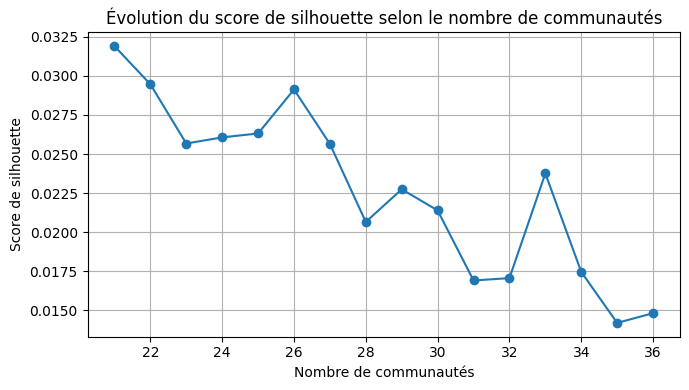

Meilleur score silhouette : 0.0238
Nombre de communautés : 33


In [45]:
from networkx.algorithms.community.centrality import girvan_newman
from networkx import edge_betweenness_centrality as betweenness
from sklearn.metrics import silhouette_score
def most_central_edge(G):
    centrality = betweenness(G, weight="weight")
    return max(centrality, key=centrality.get)
partition = nx.community.girvan_newman(G, most_valuable_edge=most_central_edge)
# Générer les partitions (limité à k=2 à 10 communautés pour éviter trop de calculs)
silhouette_scores = []
partition_lengths = []
best_score = -1
best_partition = None
for communities in partition:
    n_communities = len(communities)
    partition_lengths.append(n_communities)
    print(f"Nombre de communautés : {n_communities}")
    labels = np.zeros(len(G.nodes()), dtype=int)
    for idx, community in enumerate(communities):
        for node in community:
            labels[list(G.nodes()).index(node)] = idx
    # Calcul du score silhouette sur les centroïdes (distance_matrix)
    score = silhouette_score(distance_matrix, labels, metric='precomputed')
    silhouette_scores.append(score)
    if score > best_score or n_communities == 33:
        best_score = score
        best_partition = communities
    if n_communities >= 36:
        break

# Tracer l'évolution du score de silhouette
plt.figure(figsize=(7, 4))
plt.plot(partition_lengths, silhouette_scores, marker='o')
plt.xlabel("Nombre de communautés")
plt.ylabel("Score de silhouette")
plt.title("Évolution du score de silhouette selon le nombre de communautés")
plt.grid(True)
plt.tight_layout()
plt.show()
print(f"Meilleur score silhouette : {best_score:.4f}")
print(f"Nombre de communautés : {len(best_partition)}")

In [46]:
import math

# Définir une colormap bleu-rouge pour les poids des arêtes
import matplotlib
import numpy as np
cmap = matplotlib.cm.get_cmap('coolwarm')
# Générer une couleur différente pour chaque communauté
import matplotlib.colors as mcolors

# Utiliser la meilleure partition trouvée précédemment
communities = best_partition
num_communities = len(communities)
colors = list(mcolors.TABLEAU_COLORS.values())
if num_communities > len(colors):
    # Générer plus de couleurs si besoin
    cmap_communities = matplotlib.cm.get_cmap('tab20', num_communities)
    colors = [matplotlib.colors.rgb2hex(cmap_communities(i)) for i in range(num_communities)]

# Attribuer une couleur à chaque noeud selon sa communauté
node_community_color = {}
for idx, community in enumerate(communities):
    for node in community:
        node_community_color[node] = colors[idx]

# Ajouter la couleur au graphe
for node in G.nodes():
    G.nodes[node]['color'] = node_community_color[node]

# Calculer la disposition des communautés en cercles
layout = {}
radius_outer = 1.5
radius_inner = 0.4
angle_step_outer = 2 * np.pi / num_communities

for idx, community in enumerate(communities):
    angle_center = idx * angle_step_outer
    cx = radius_outer * np.cos(angle_center)
    cy = radius_outer * np.sin(angle_center)
    n_nodes = len(community)
    angle_step_inner = 2 * np.pi / max(n_nodes, 1)
    for j, node in enumerate(community):
        angle = j * angle_step_inner
        layout[node] = {
            "x": cx + radius_inner * np.cos(angle),
            "y": cy + radius_inner * np.sin(angle)
        }

# Calcul d'un score de PageRank pour ajuster la taille des noeuds par exemple
pagerank_scores = nx.pagerank(G)

# Visualisation avec ipysigma
sigma = Sigma(
    graph=G,
    raw_node_color="color",
    raw_edge_color="color_edge",
    layout=layout,
    node_label="nom complet",
    default_edge_type="curve",
    label_font="cursive",
    node_size=pagerank_scores,  # On peut également multiplier par un facteur si nécessaire
)

# Pour afficher dans Jupyter Notebook (si ipysigma est intégré dans un widget)
sigma

C:\Users\PCAJM\AppData\Local\Temp\ipykernel_18172\3783730569.py:6: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.

C:\Users\PCAJM\AppData\Local\Temp\ipykernel_18172\3783730569.py:16: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



Sigma(nx.Graph with 70 nodes and 385 edges)